# WARNING: ⚠️ DON't USE NOW: I WILL FIX IT LATER

# EDA — Synthetic VPD Coverage Data

This notebook explores the synthetic coverage data generated by the `imuGAP` package.
The synthetic fixtures include both Dose 1 (State-level child view, 24/36 months) and Dose 2 (School-level view).
The goal of this EDA is to identify baseline vulnerabilities and understand the current geographical distribution of immunity, 
setting the stage for our core research question: 

*"How will a 10% reduction MCV1 coverage affect measles transmission in NC?"*

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

# Setup plotting style
plt.rcParams['figure.figsize'] = (10, 6)
sns.set_theme(style="whitegrid")

## 1. Load Synthetic Data
We will load the synthetic fixtures (locations and observations) and merge them to establish the geographical hierarchy.

In [7]:
# Define paths
DATA_DIR = Path("../data")
if not DATA_DIR.exists():
    DATA_DIR = Path("data")
locations_path = DATA_DIR / "synthetic_locations.csv"
observations_path = DATA_DIR / "synthetic_observations.csv"

# Load data
locations_df = pd.read_csv(locations_path)
obs_df = pd.read_csv(observations_path)

# Calculate empirical coverage
obs_df['empirical_coverage'] = obs_df['positive'] / obs_df['sample_n']

print(f"Total observations: {obs_df.shape[0]}")
obs_df.head()

Total observations: 698


,loc_id,parent_id,year,enc_unit_id,unit_id,positive,sample_n,ly_min,ly_max,dose,weight,vaxview_type,age,censored,cohort_min,cohort_max,obs_id,empirical_coverage
0,Chickadee Elementary,Scruggs,2001,2.0,5,15,17,5,5,2,1.0,NaN,NaN,NaN,4,4,1,0.882353
1,Chickadee Elementary,Scruggs,2002,2.0,5,14,22,5,5,2,1.0,NaN,NaN,NaN,5,5,2,0.636364
2,Chickadee Elementary,Scruggs,2003,2.0,5,17,20,5,5,2,1.0,NaN,NaN,NaN,6,6,3,0.850000
3,Chickadee Elementary,Scruggs,2004,2.0,5,19,24,5,5,2,1.0,NaN,NaN,NaN,7,7,4,0.791667
4,Chickadee Elementary,Scruggs,2005,2.0,5,16,22,5,5,2,1.0,NaN,NaN,NaN,8,8,5,0.727273


## 2. Filter for School-Level Data
The raw synthetic observations for Dose 1 are only at the "State" level. To explore the geographical distribution (counties/schools), we must look at the school entry data (`dose == 2`), which will give us the starting point for immunity across the state before we model MCV1 drops.

In [8]:
# Filter for school-level data (which has parent_id / county information)
school_df = obs_df[(obs_df['dose'] == 2) & (obs_df['parent_id'].notna())].copy()
print(f"School-level observations: {school_df.shape[0]}")
school_df.head()

School-level observations: 600


,loc_id,parent_id,year,enc_unit_id,unit_id,positive,sample_n,ly_min,ly_max,dose,weight,vaxview_type,age,censored,cohort_min,cohort_max,obs_id,empirical_coverage
0,Chickadee Elementary,Scruggs,2001,2.0,5,15,17,5,5,2,1.0,NaN,NaN,NaN,4,4,1,0.882353
1,Chickadee Elementary,Scruggs,2002,2.0,5,14,22,5,5,2,1.0,NaN,NaN,NaN,5,5,2,0.636364
2,Chickadee Elementary,Scruggs,2003,2.0,5,17,20,5,5,2,1.0,NaN,NaN,NaN,6,6,3,0.850000
3,Chickadee Elementary,Scruggs,2004,2.0,5,19,24,5,5,2,1.0,NaN,NaN,NaN,7,7,4,0.791667
4,Chickadee Elementary,Scruggs,2005,2.0,5,16,22,5,5,2,1.0,NaN,NaN,NaN,8,8,5,0.727273


## 3. Distribution of Baseline Coverage
Let's see where schools generally sit in terms of their reported coverage.

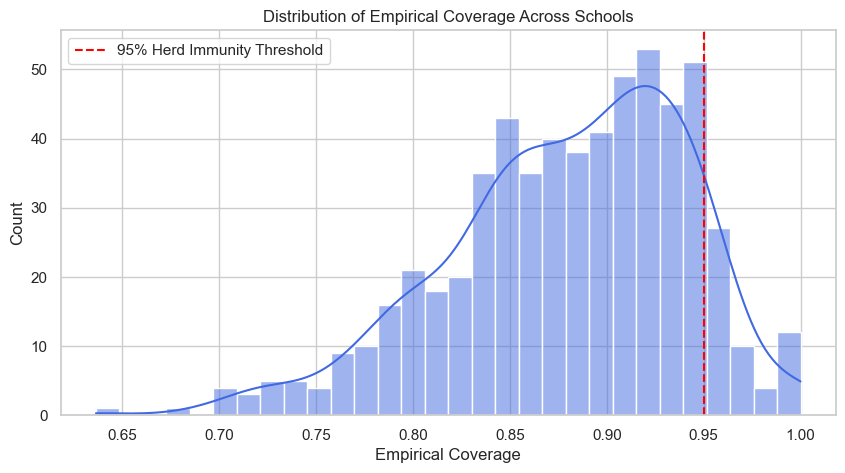

In [9]:
plt.figure(figsize=(10, 5))
sns.histplot(school_df['empirical_coverage'], bins=30, kde=True, color='royalblue')
plt.axvline(0.95, color='red', linestyle='--', label='95% Herd Immunity Threshold')
plt.title('Distribution of Empirical Coverage Across Schools')
plt.xlabel('Empirical Coverage')
plt.ylabel('Count')
plt.legend()
plt.show()

## 4. County-Level Comparisons
Are certain counties more vulnerable than others? We examine the distribution of school-level coverage grouped by county.

/var/folders/6h/kzybnmtn31sg6w__1bm1v8d00000gn/T/ipykernel_64055/2914698286.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=school_df, x='parent_id', y='empirical_coverage', palette='Set2')


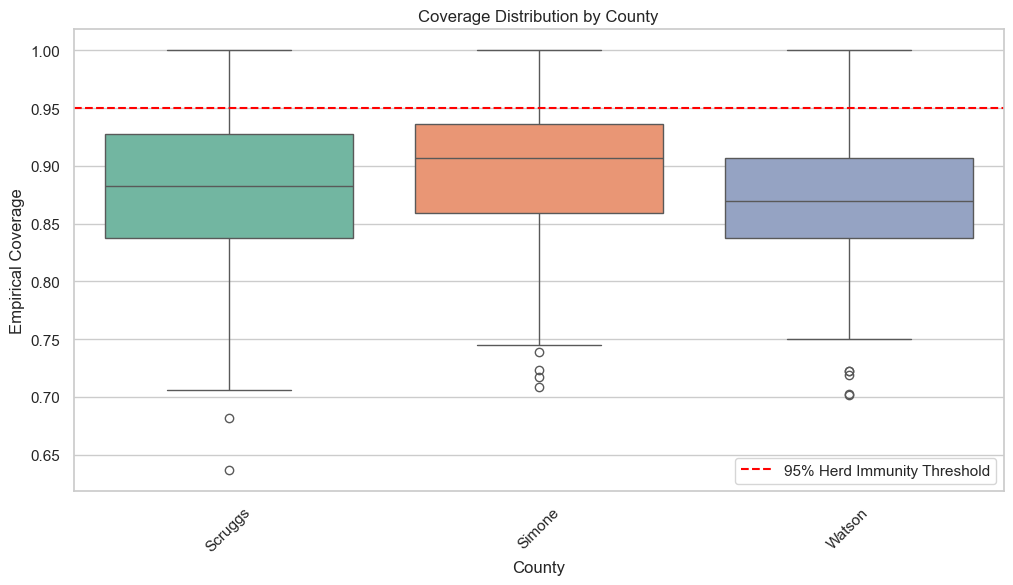

In [10]:
plt.figure(figsize=(12, 6))
sns.boxplot(data=school_df, x='parent_id', y='empirical_coverage', palette='Set2')
plt.axhline(0.95, color='red', linestyle='--', label='95% Herd Immunity Threshold')
plt.title('Coverage Distribution by County')
plt.xlabel('County')
plt.ylabel('Empirical Coverage')
plt.legend()
plt.xticks(rotation=45)
plt.show()

## 5. Vulnerability to a 10% Reduction
What happens to herd immunity if coverage drops by 10%? We use the school-level data as a proxy for the baseline vulnerability.

Currently, 89.7% of observations are below the 95% threshold.
With a 10% reduction in coverage, 100.0% of observations would fall below 95%.


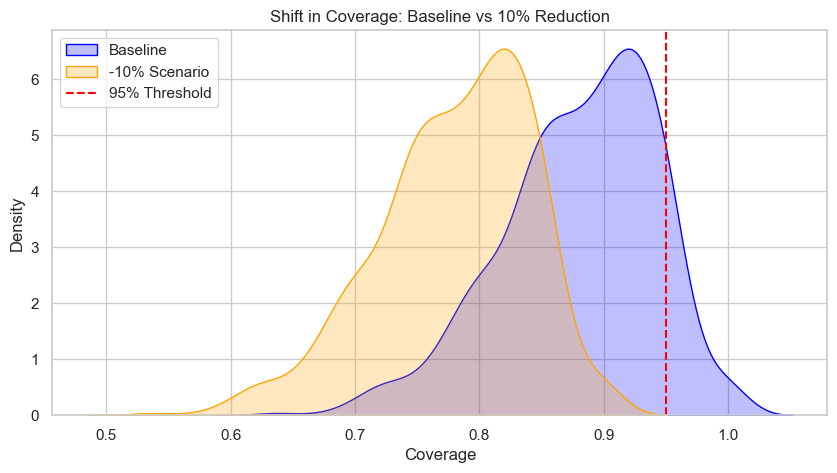

In [11]:
# Current state
schools_below_95_current = (school_df['empirical_coverage'] < 0.95).mean() * 100

# What-if scenario: 10% reduction
school_df['coverage_reduced'] = school_df['empirical_coverage'] - 0.10
schools_below_95_reduced = (school_df['coverage_reduced'] < 0.95).mean() * 100

print(f"Currently, {schools_below_95_current:.1f}% of observations are below the 95% threshold.")
print(f"With a 10% reduction in coverage, {schools_below_95_reduced:.1f}% of observations would fall below 95%.")

# Visualize the shift
plt.figure(figsize=(10, 5))
sns.kdeplot(school_df['empirical_coverage'], fill=True, label='Baseline', color='blue')
sns.kdeplot(school_df['coverage_reduced'], fill=True, label='-10% Scenario', color='orange')
plt.axvline(0.95, color='red', linestyle='--', label='95% Threshold')
plt.title('Shift in Coverage: Baseline vs 10% Reduction')
plt.xlabel('Coverage')
plt.legend()
plt.show()

## 6. Time / Cohort Trends
Let's see if there are noticeable trends across cohorts for the State-level MCV1 (Dose 1) observations, since this is the primary focus of our model scenario.

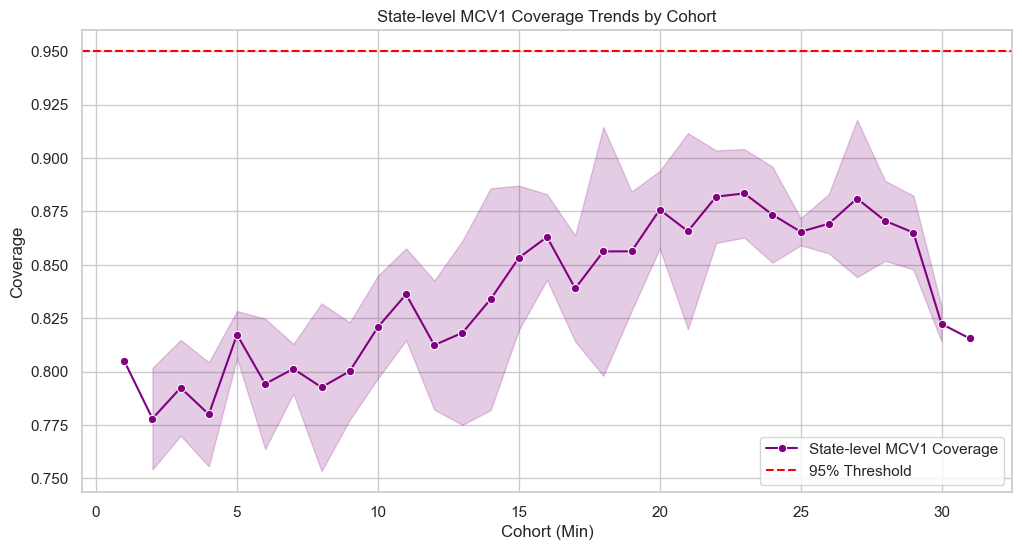

In [12]:
state_mcv1_df = obs_df[obs_df['dose'] == 1].copy()

plt.figure(figsize=(12, 6))
sns.lineplot(data=state_mcv1_df, x='cohort_min', y='empirical_coverage', estimator='mean', errorbar='ci', color='purple', marker='o', label='State-level MCV1 Coverage')
plt.axhline(0.95, color='red', linestyle='--', label='95% Threshold')
plt.title('State-level MCV1 Coverage Trends by Cohort')
plt.xlabel('Cohort (Min)')
plt.ylabel('Coverage')
plt.legend()
plt.show()